# Notebook 03 — NLP / Named Entity Recognition

**Goal:** Extract medical entities from clinical notes using NLP.

**Input:** `platform/data/notes_linked.csv` — 4,966 clinical transcription notes

**Tasks:**
- Extract medical entities: conditions, symptoms, treatments, medications
- Identify note topics and specialties
- Summarize key medical information per note

**Output:** `platform/outputs/nlp_results.csv`

## 1. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import os
import re
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from tqdm import tqdm

import spacy

DATA_DIR   = "../data/"
OUTPUT_DIR = "../outputs/"

os.makedirs(OUTPUT_DIR, exist_ok=True)

# Load spaCy model for NER
nlp = spacy.load("en_core_web_sm")
print("spaCy model loaded")
print(f"spaCy version: {spacy.__version__}")

spaCy model loaded
spaCy version: 3.8.14


## 2. Load Data

In [2]:
notes_df = pd.read_csv(os.path.join(DATA_DIR, "notes_linked.csv"))

print(f"Loaded: {notes_df.shape}")
print()
print("Columns:")
print(notes_df.columns.tolist())
print()
print("Sample note:")
print(notes_df["transcription"].iloc[0][:500])

Loaded: (4966, 7)

Columns:
['patient_id', 'match_type', 'description', 'medical_specialty', 'sample_name', 'transcription', 'keywords']

Sample note:
SUBJECTIVE:,  This 23-year-old white female presents with complaint of allergies.  She used to have allergies when she lived in Seattle but she thinks they are worse here.  In the past, she has tried Claritin, and Zyrtec.  Both worked for short time but then seemed to lose effectiveness.  She has used Allegra also.  She used that last summer and she began using it again two weeks ago.  It does not appear to be working very well.  She has used over-the-counter sprays but no prescription nasal spr


## 3. Define Medical Entity Patterns

In [3]:
# Regex patterns to extract medical entities
# These are common medical terms found in clinical notes

CONDITION_KEYWORDS = [
    r'\b(diabetes|hypertension|asthma|arthritis|obesity|cancer|stroke|heart disease|'
    r'copd|pneumonia|bronchitis|gerd|ibs|crohns|appendicitis|kidney disease|'
    r'thyroid|anxiety|depression|migraine|fracture|sprain|osteoporosis|anemia)\b'
]

SYMPTOM_KEYWORDS = [
    r'\b(pain|chest pain|shortness of breath|fever|cough|nausea|vomiting|dizziness|'
    r'fatigue|headache|weakness|tremor|swelling|rash|itching|bleeding|discharge)\b'
]

MEDICATION_KEYWORDS = [
    r'\b(aspirin|ibuprofen|acetaminophen|amoxicillin|penicillin|lisinopril|metformin|'
    r'atorvastatin|simvastatin|omeprazole|sertraline|fluoxetine|insulin|albuterol|'
    r'metoprolol|amlodipine|furosemide|hydrochlorothiazide)\b'
]

TREATMENT_KEYWORDS = [
    r'\b(surgery|medication|therapy|exercise|diet|rest|physical therapy|'
    r'chemotherapy|radiation|dialysis|transfusion|ventilation|intubation)\b'
]

print("Medical entity patterns defined:")
print(f"  - Conditions: {len(CONDITION_KEYWORDS)} patterns")
print(f"  - Symptoms: {len(SYMPTOM_KEYWORDS)} patterns")
print(f"  - Medications: {len(MEDICATION_KEYWORDS)} patterns")
print(f"  - Treatments: {len(TREATMENT_KEYWORDS)} patterns")

Medical entity patterns defined:
  - Conditions: 1 patterns
  - Symptoms: 1 patterns
  - Medications: 1 patterns
  - Treatments: 1 patterns


## 4. Extract Medical Entities

In [4]:
def extract_entities(text):
    """
    Extract medical entities from clinical note text.
    Returns dict with lists of found entities.
    """
    if pd.isna(text):
        return {
            'conditions': [],
            'symptoms': [],
            'medications': [],
            'treatments': []
        }

    text_lower = str(text).lower()
    entities = {
        'conditions': [],
        'symptoms': [],
        'medications': [],
        'treatments': []
    }

    # Extract conditions
    for pattern in CONDITION_KEYWORDS:
        matches = re.findall(pattern, text_lower, re.IGNORECASE)
        entities['conditions'].extend(matches)

    # Extract symptoms
    for pattern in SYMPTOM_KEYWORDS:
        matches = re.findall(pattern, text_lower, re.IGNORECASE)
        entities['symptoms'].extend(matches)

    # Extract medications
    for pattern in MEDICATION_KEYWORDS:
        matches = re.findall(pattern, text_lower, re.IGNORECASE)
        entities['medications'].extend(matches)

    # Extract treatments
    for pattern in TREATMENT_KEYWORDS:
        matches = re.findall(pattern, text_lower, re.IGNORECASE)
        entities['treatments'].extend(matches)

    # Remove duplicates while preserving order
    for key in entities:
        entities[key] = list(dict.fromkeys(entities[key]))

    return entities


# Test on first note
test_entities = extract_entities(notes_df["transcription"].iloc[0])
print("Sample extraction from first note:")
print(f"  Conditions: {test_entities['conditions']}")
print(f"  Symptoms: {test_entities['symptoms']}")
print(f"  Medications: {test_entities['medications']}")
print(f"  Treatments: {test_entities['treatments']}")

Sample extraction from first note:
  Conditions: ['asthma']
  Symptoms: []
  Medications: []
  Treatments: ['medication']


## 5. Extract Entities from All Notes

In [5]:
print("Extracting medical entities from all notes...")
print()

results = []
for idx, row in tqdm(notes_df.iterrows(), total=len(notes_df)):
    entities = extract_entities(row['transcription'])

    results.append({
        'patient_id': row['patient_id'],
        'medical_specialty': row['medical_specialty'],
        'text_length': len(str(row['transcription'])),
        'num_sentences': len(str(row['transcription']).split('.')),
        'conditions_found': ', '.join(entities['conditions']) if entities['conditions'] else 'None',
        'num_conditions': len(entities['conditions']),
        'symptoms_found': ', '.join(entities['symptoms']) if entities['symptoms'] else 'None',
        'num_symptoms': len(entities['symptoms']),
        'medications_found': ', '.join(entities['medications']) if entities['medications'] else 'None',
        'num_medications': len(entities['medications']),
        'treatments_found': ', '.join(entities['treatments']) if entities['treatments'] else 'None',
        'num_treatments': len(entities['treatments']),
    })

nlp_results = pd.DataFrame(results)
print(f"Extraction complete: {len(nlp_results)} notes processed")

Extracting medical entities from all notes...



100%|██████████| 4966/4966 [00:07<00:00, 653.82it/s]

Extraction complete: 4966 notes processed


## 6. NLP Results Overview

In [6]:
print("=== NLP Extraction Results ===")
print()
print("Entity extraction coverage:")
print(f"  Notes with conditions   : {(nlp_results['num_conditions'] > 0).sum()} ({(nlp_results['num_conditions'] > 0).mean()*100:.1f}%)")
print(f"  Notes with symptoms     : {(nlp_results['num_symptoms'] > 0).sum()} ({(nlp_results['num_symptoms'] > 0).mean()*100:.1f}%)")
print(f"  Notes with medications  : {(nlp_results['num_medications'] > 0).sum()} ({(nlp_results['num_medications'] > 0).mean()*100:.1f}%)")
print(f"  Notes with treatments   : {(nlp_results['num_treatments'] > 0).sum()} ({(nlp_results['num_treatments'] > 0).mean()*100:.1f}%)")
print()
print("Average entities per note:")
print(f"  Conditions  : {nlp_results['num_conditions'].mean():.2f}")
print(f"  Symptoms    : {nlp_results['num_symptoms'].mean():.2f}")
print(f"  Medications : {nlp_results['num_medications'].mean():.2f}")
print(f"  Treatments  : {nlp_results['num_treatments'].mean():.2f}")
print()
print("Sample results:")
print(nlp_results[['patient_id', 'medical_specialty', 'conditions_found', 'symptoms_found']].head(5))

=== NLP Extraction Results ===

Entity extraction coverage:
  Notes with conditions   : 2060 (41.5%)
  Notes with symptoms     : 3204 (64.5%)
  Notes with medications  : 812 (16.4%)
  Notes with treatments   : 2470 (49.7%)

Average entities per note:
  Conditions  : 0.89
  Symptoms    : 1.62
  Medications : 0.28
  Treatments  : 0.75

Sample results:
                             patient_id            medical_specialty  \
0  8a69ae35-07ad-e093-0162-ad02d8e1e070         Allergy / Immunology   
1  e25be42f-7103-4d46-f926-f9eb6f6381b2                   Bariatrics   
2  97a20cf9-630d-939c-2f50-f13c434aee2f                   Bariatrics   
3  6fc7b50b-61ff-9237-bcac-7b7b1d8606ab   Cardiovascular / Pulmonary   
4  845a3922-0b68-9036-172a-57b58f1ff684   Cardiovascular / Pulmonary   

                                    conditions_found  \
0                                             asthma   
1  heart disease, stroke, diabetes, obesity, hype...   
2  asthma, obesity, heart disease, diabetes, hy

## 7. Entity Frequency Analysis

In [7]:
# Count frequency of each entity across all notes
all_conditions = []
all_symptoms = []
all_medications = []
all_treatments = []

for idx, row in nlp_results.iterrows():
    if pd.notna(row['conditions_found']) and row['conditions_found'] != 'None':
        all_conditions.extend(row['conditions_found'].split(', '))
    if pd.notna(row['symptoms_found']) and row['symptoms_found'] != 'None':
        all_symptoms.extend(row['symptoms_found'].split(', '))
    if pd.notna(row['medications_found']) and row['medications_found'] != 'None':
        all_medications.extend(row['medications_found'].split(', '))
    if pd.notna(row['treatments_found']) and row['treatments_found'] != 'None':
        all_treatments.extend(row['treatments_found'].split(', '))

print("=== Most Frequent Entities ===")
print()
print("Top 10 conditions:")
print(pd.Series(all_conditions).value_counts().head(10))
print()
print("Top 10 symptoms:")
print(pd.Series(all_symptoms).value_counts().head(10))
print()
print("Top 10 medications:")
print(pd.Series(all_medications).value_counts().head(10))
print()
print("Top 10 treatments:")
print(pd.Series(all_treatments).value_counts().head(10))

=== Most Frequent Entities ===

Top 10 conditions:
hypertension    686
diabetes        509
cancer          460
fracture        290
thyroid         263
depression      257
anemia          228
stroke          215
pneumonia       210
arthritis       204
Name: count, dtype: int64

Top 10 symptoms:
pain                   1766
bleeding               1020
discharge               569
vomiting                555
chest pain              546
nausea                  533
shortness of breath     500
fever                   488
weakness                465
swelling                428
Name: count, dtype: int64

Top 10 medications:
aspirin                315
penicillin             138
insulin                138
lisinopril             118
albuterol               99
metoprolol              96
hydrochlorothiazide     72
ibuprofen               72
metformin               62
amoxicillin             55
Name: count, dtype: int64

Top 10 treatments:
surgery             1197
therapy              473
medication  

## 8. Visualization

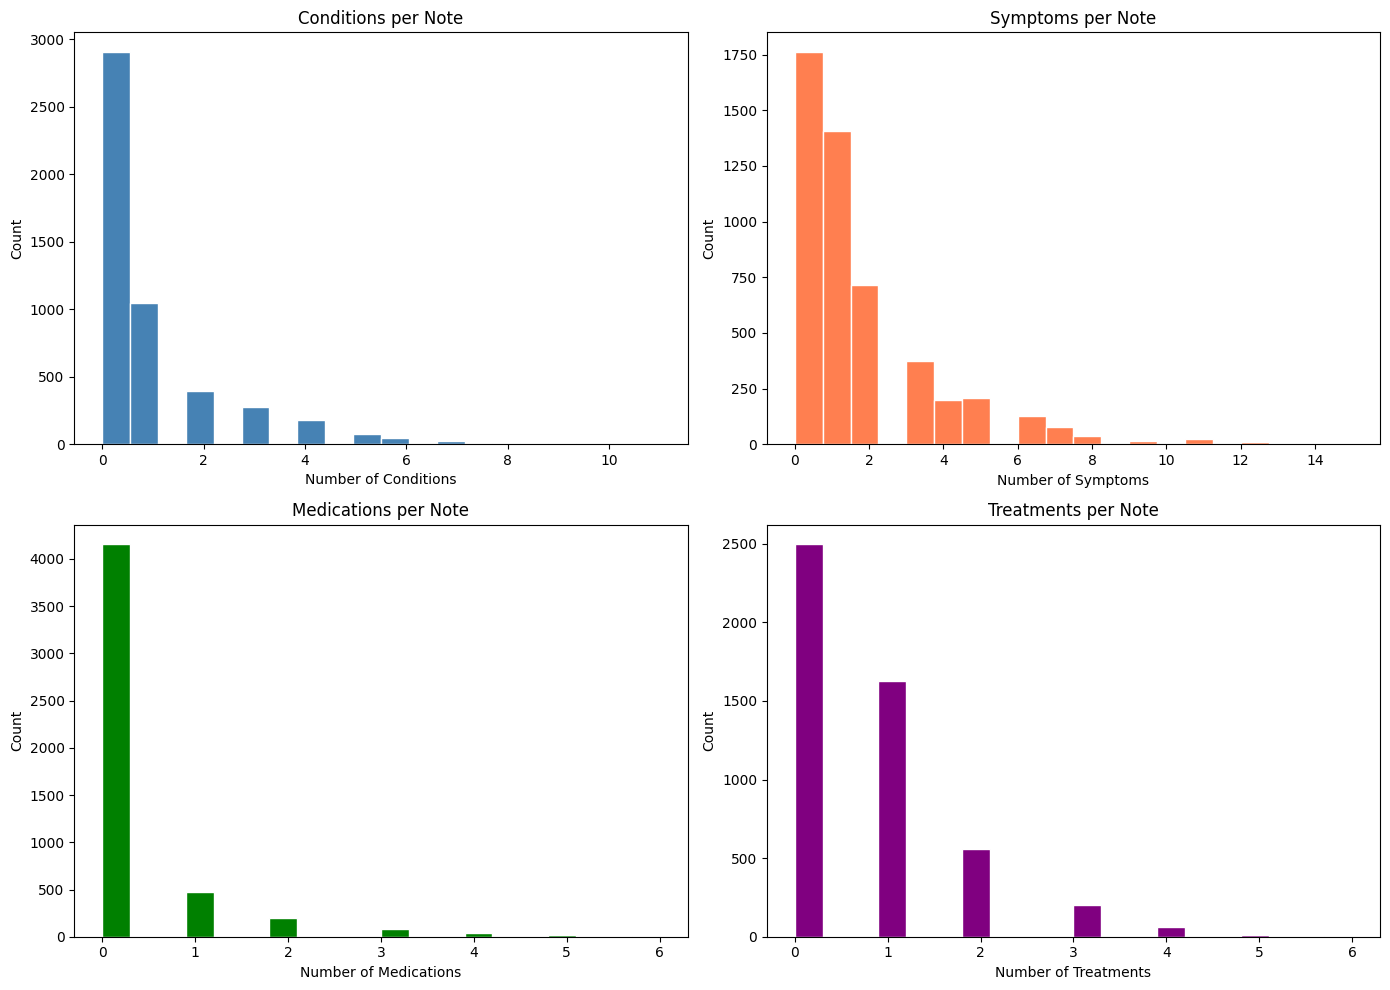

Saved → nlp_entity_distribution.png


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Entities per note
axes[0, 0].hist(nlp_results['num_conditions'], bins=20, color='steelblue', edgecolor='white')
axes[0, 0].set_title('Conditions per Note')
axes[0, 0].set_xlabel('Number of Conditions')
axes[0, 0].set_ylabel('Count')

axes[0, 1].hist(nlp_results['num_symptoms'], bins=20, color='coral', edgecolor='white')
axes[0, 1].set_title('Symptoms per Note')
axes[0, 1].set_xlabel('Number of Symptoms')
axes[0, 1].set_ylabel('Count')

axes[1, 0].hist(nlp_results['num_medications'], bins=20, color='green', edgecolor='white')
axes[1, 0].set_title('Medications per Note')
axes[1, 0].set_xlabel('Number of Medications')
axes[1, 0].set_ylabel('Count')

axes[1, 1].hist(nlp_results['num_treatments'], bins=20, color='purple', edgecolor='white')
axes[1, 1].set_title('Treatments per Note')
axes[1, 1].set_xlabel('Number of Treatments')
axes[1, 1].set_ylabel('Count')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'nlp_entity_distribution.png'), dpi=100)
plt.show()
print("Saved → nlp_entity_distribution.png")

## 9. Quality Check

In [9]:
print("=== NLP Processing Quality Check ===")
print()
print(f"Total notes processed      : {len(nlp_results)}")
print(f"Notes with at least 1 entity: {(nlp_results[['num_conditions', 'num_symptoms', 'num_medications', 'num_treatments']].sum(axis=1) > 0).sum()}")
print(f"Notes with no entities     : {(nlp_results[['num_conditions', 'num_symptoms', 'num_medications', 'num_treatments']].sum(axis=1) == 0).sum()}")
print()
print("Entities by specialty:")
spec_summary = nlp_results.groupby('medical_specialty')[['num_conditions', 'num_symptoms', 'num_medications', 'num_treatments']].mean()
print(spec_summary.round(2).head(10))
print()
print("Final columns:")
print(nlp_results.columns.tolist())

=== NLP Processing Quality Check ===

Total notes processed      : 4966
Notes with at least 1 entity: 4026
Notes with no entities     : 940

Entities by specialty:
                            num_conditions  num_symptoms  num_medications  \
medical_specialty                                                           
Allergy / Immunology                  1.86          2.14             0.43   
Autopsy                               1.12          0.38             0.00   
Bariatrics                            3.11          2.06             0.44   
Cardiovascular / Pulmonary            0.95          1.24             0.46   
Chiropractic                          1.43          2.14             0.36   
Consult - History and Phy.            2.24          3.12             0.74   
Cosmetic / Plastic Surgery            0.30          0.48             0.00   
Dentistry                             0.30          1.52             0.19   
Dermatology                           0.52          1.21          

## 10. Save Output

In [10]:
output_path = os.path.join(OUTPUT_DIR, "nlp_results.csv")
nlp_results.to_csv(output_path, index=False)

print(f"Saved → {output_path}")
print(f"Shape  : {nlp_results.shape}")

Saved → ../outputs/nlp_results.csv
Shape  : (4966, 12)
